<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/1_Unsupervised_Learning_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning: Clustering Algorithms

This notebook accompanies the *Unsupervised Learning — Clustering Algorithms* presentation.
It walks through the **3 most popular clustering algorithms**, with working, runnable Python code for each:

1. **K-Means** — centroid-based partitioning
2. **Hierarchical Clustering (Agglomerative)** — tree-based nesting
3. **DBSCAN** — density-based grouping

For each algorithm you'll find:
- A short explanation of how it works
- A runnable code example on synthetic data
- A visualization of the resulting clusters
- Notes on strengths, weaknesses, and when to use it

At the end there's a side-by-side comparison and a demonstration of *why* algorithm choice matters (spherical vs. non-spherical data).

## 0. Setup

Import the libraries we'll use throughout the notebook. All of these ship with `scikit-learn`, `scipy`, `numpy`, and `matplotlib`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# Consistent color palette used across all plots
PALETTE = ["#6366F1", "#F59E0B", "#10B981", "#F43F5E", "#8B5CF6", "#0EA5E9"]
NOISE_COLOR = "#CBD5E1"

plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

## 1. What Is Unsupervised Learning?

**Unsupervised learning** is a branch of machine learning where the model learns patterns from data that has **no labels** — there is no "correct answer" provided during training.

| | Supervised | Unsupervised |
|---|---|---|
| Data | Labeled (input → known output) | Unlabeled |
| Goal | Predict a target (class or value) | Discover hidden structure |
| Examples | Spam detection, price prediction | Customer segmentation, anomaly detection |

**Clustering** is the most common unsupervised learning task: grouping data points so that points in the same group (cluster) are more similar to each other than to points in other groups.

Common applications:
- 🛍️ **Customer segmentation** — group shoppers by behavior for targeted marketing
- 🧬 **Bioinformatics** — group genes or proteins with similar expression
- 🖼️ **Image compression** — reduce colors by grouping similar pixel values
- 🚨 **Anomaly detection** — flag points that don't belong to any cluster

---
## 2. K-Means Clustering

**K-Means** partitions data into **k** clusters, where each point belongs to the cluster with the nearest mean (centroid).

### How it works
1. **Choose k** — pick the number of clusters to form.
2. **Initialize centroids** — place k centroids randomly in the feature space.
3. **Assign points** — assign each point to its nearest centroid.
4. **Update centroids** — recompute each centroid as the mean of its assigned points.
5. **Repeat** steps 3–4 until assignments stop changing (convergence).

### At a glance
| | |
|---|---|
| **Best for** | Spherical, evenly-sized clusters |
| **Time complexity** | O(n · k · i · d) — fast & scalable |
| **Key parameter** | `k` (number of clusters) |
| **Handles noise?** | No — sensitive to outliers |

### 2.1 Create synthetic data

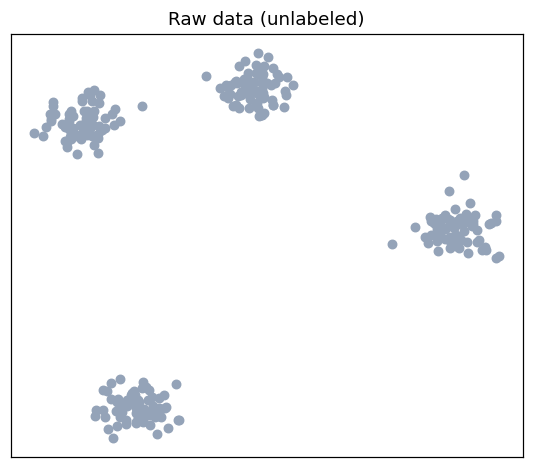

In [ ]:
# Generate 4 well-separated blobs of points
X_blobs, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=30, color="#94A3B8")
plt.title("Raw data (unlabeled)")
plt.xticks([]); plt.yticks([])
plt.show()

### 2.2 Fit K-Means

In [ ]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans.fit(X_blobs)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster sizes:", np.bincount(labels))
print("Inertia (sum of squared distances to nearest centroid):", round(kmeans.inertia_, 2))

Cluster sizes: [75 75 75 75]
Inertia (sum of squared distances to nearest centroid): 277.52


### 2.3 Visualize the result

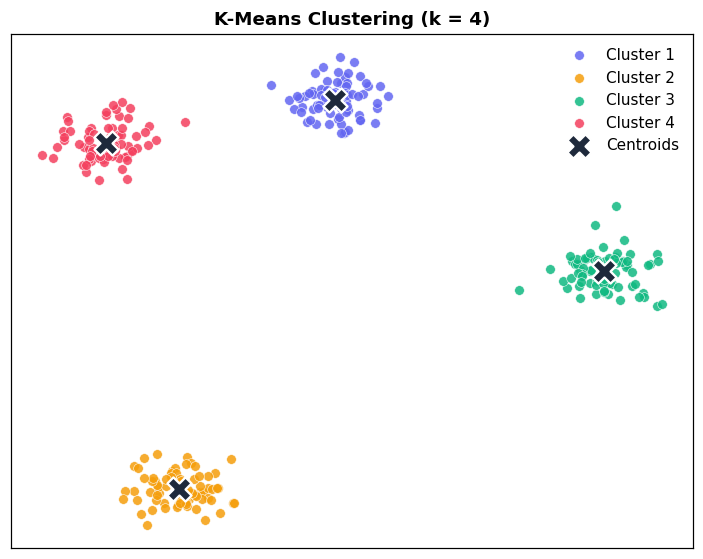

In [ ]:
plt.figure(figsize=(6.5, 5.2))
for i in range(4):
    pts = X_blobs[labels == i]
    plt.scatter(pts[:, 0], pts[:, 1], s=40, color=PALETTE[i], alpha=0.85,
                edgecolor="white", linewidth=0.4, label=f"Cluster {i+1}")

plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c="#1E293B", marker="X",
            edgecolor="white", linewidth=1.5, label="Centroids", zorder=5)
plt.title("K-Means Clustering (k = 4)", fontweight="bold")
plt.xticks([]); plt.yticks([])
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### 2.4 Choosing k: the Elbow Method

In practice you rarely know `k` in advance. The **elbow method** fits K-Means for a range of `k` values and plots the inertia — the point where the improvement starts to flatten out ("the elbow") is a good candidate for `k`.

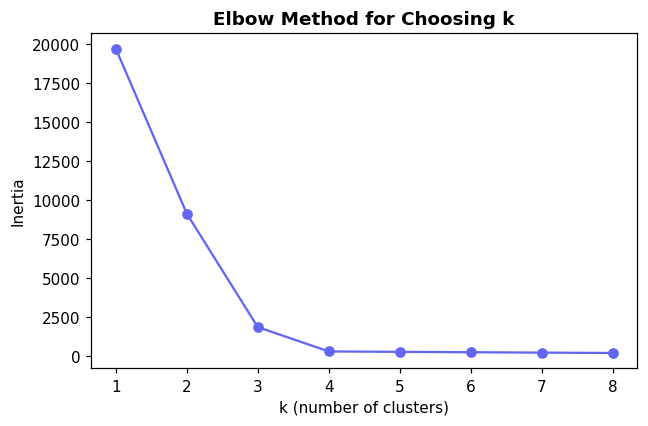

In [ ]:
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o", color=PALETTE[0])
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing k", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. Hierarchical Clustering (Agglomerative)

**Hierarchical clustering** builds a tree of nested clusters by repeatedly merging the two closest clusters until only one remains. The result is usually visualized as a **dendrogram**.

### How it works
1. **Start with singletons** — treat every data point as its own cluster.
2. **Compute distances** — measure distance between all pairs of clusters.
3. **Merge closest pair** — combine the two nearest clusters into one.
4. **Repeat** — continue merging until only one cluster remains.
5. **Cut the dendrogram** — choose a height to cut the tree into k clusters.

### At a glance
| | |
|---|---|
| **Best for** | Small datasets, nested structure |
| **Time complexity** | O(n² log n) — slower on large n |
| **Key parameter** | Linkage method (`ward`, `average`, `complete`...) |
| **Handles noise?** | Moderately — sensitive to outliers |

### 3.1 Create synthetic data

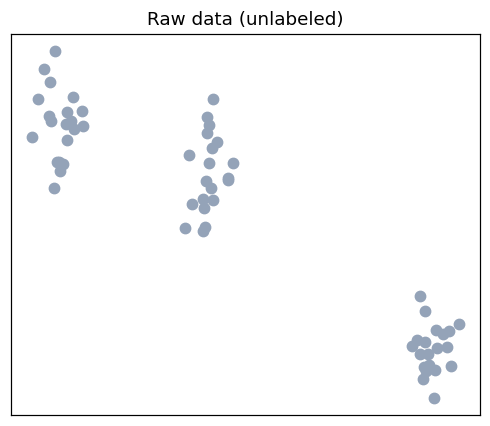

In [ ]:
X_hier, _ = make_blobs(n_samples=60, centers=3, cluster_std=0.65, random_state=7)

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X_hier[:, 0], X_hier[:, 1], s=45, color="#94A3B8")
plt.title("Raw data (unlabeled)")
plt.xticks([]); plt.yticks([])
plt.show()

### 3.2 Compute the linkage matrix and plot the dendrogram

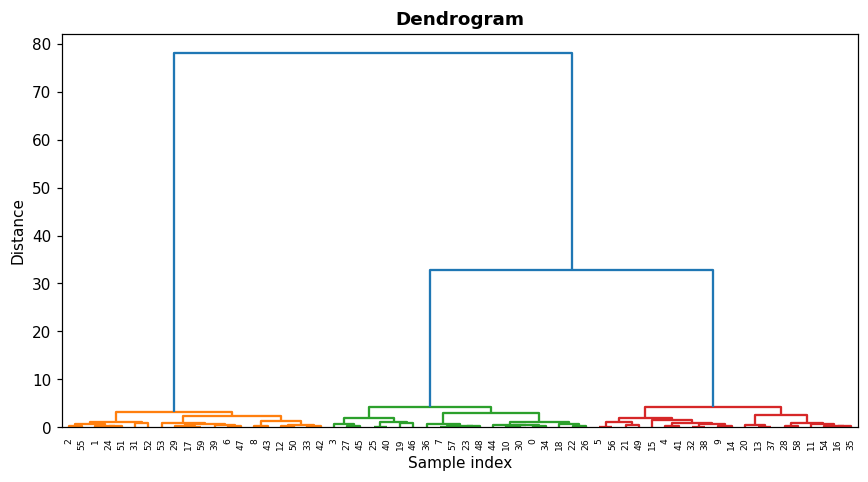

In [ ]:
# 'ward' linkage minimizes the variance within each merged cluster
Z = linkage(X_hier, method="ward")

plt.figure(figsize=(8, 4.5))
dendrogram(Z, color_threshold=7)
plt.title("Dendrogram", fontweight="bold")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

The dendrogram shows the order in which points/clusters were merged, and the distance ("height") at which each merge happened. Cutting the tree horizontally at a chosen height determines how many clusters you end up with — the fewer merges you allow, the more clusters you keep.

### 3.3 Cut the tree into k clusters

In [ ]:
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
hier_labels = agg.fit_predict(X_hier)

print("Clusters found:", len(set(hier_labels)))
print("Cluster sizes:", np.bincount(hier_labels))

Clusters found: 3
Cluster sizes: [20 20 20]


### 3.4 Visualize the result

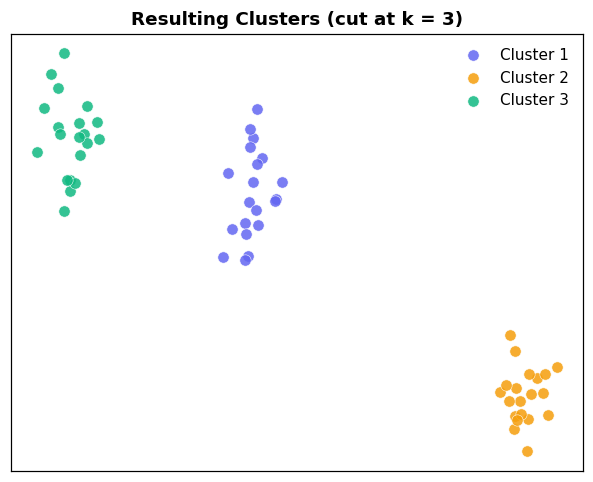

In [ ]:
plt.figure(figsize=(5.5, 4.5))
for i in range(3):
    pts = X_hier[hier_labels == i]
    plt.scatter(pts[:, 0], pts[:, 1], s=55, color=PALETTE[i], alpha=0.85,
                edgecolor="white", linewidth=0.4, label=f"Cluster {i+1}")
plt.title("Resulting Clusters (cut at k = 3)", fontweight="bold")
plt.xticks([]); plt.yticks([])
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 4. DBSCAN (Density-Based Spatial Clustering)

**DBSCAN** groups points that are closely packed together and marks isolated points as **noise**. Unlike K-Means, it does not require specifying the number of clusters in advance, and it can find clusters of arbitrary shape.

### How it works
1. **Pick `eps` & `min_samples`** — define a neighborhood radius and a density threshold.
2. **Find core points** — a point is a "core point" if at least `min_samples` other points fall within `eps` of it.
3. **Expand clusters** — connect core points and their neighbors into clusters.
4. **Reach border points** — non-core points near a cluster join that cluster.
5. **Label noise** — points reachable by no cluster are marked as noise (label `-1`).

### At a glance
| | |
|---|---|
| **Best for** | Arbitrary shapes, noisy data |
| **Time complexity** | O(n log n) with a spatial index |
| **Key parameters** | `eps` (radius), `min_samples` |
| **Handles noise?** | Yes — built-in outlier detection |

### 4.1 Create non-spherical data

This is where DBSCAN really shines: two interleaving crescent ("moon") shapes that K-Means cannot separate correctly, because K-Means assumes spherical clusters.

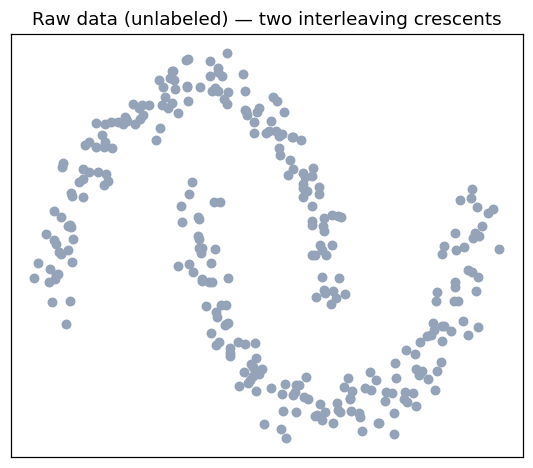

In [ ]:
X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=30, color="#94A3B8")
plt.title("Raw data (unlabeled) — two interleaving crescents")
plt.xticks([]); plt.yticks([])
plt.show()

### 4.2 Fit DBSCAN

In [ ]:
db = DBSCAN(eps=0.25, min_samples=6)
db_labels = db.fit_predict(X_moons)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print("Clusters found:", n_clusters)
print("Noise points:", n_noise)

Clusters found: 2
Noise points: 0


### 4.3 Visualize the result

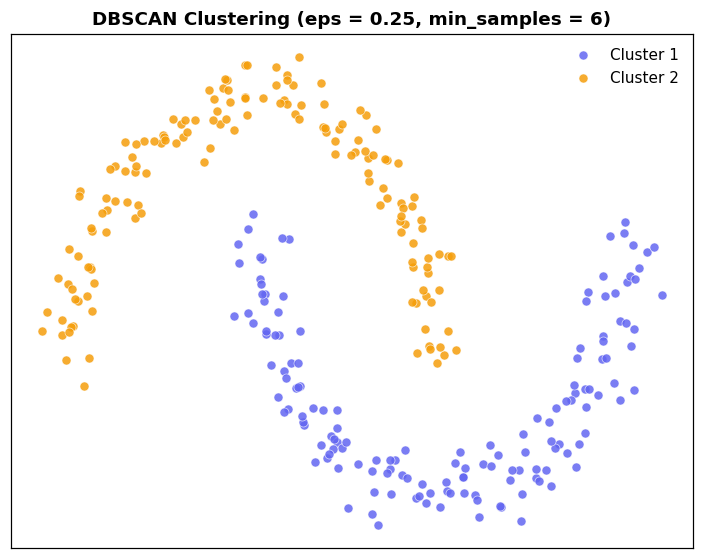

In [ ]:
plt.figure(figsize=(6.5, 5.2))
unique_labels = sorted(set(db_labels))
ci = 0
for lbl in unique_labels:
    pts = X_moons[db_labels == lbl]
    if lbl == -1:
        plt.scatter(pts[:, 0], pts[:, 1], s=35, color=NOISE_COLOR, alpha=0.9,
                    edgecolor="white", linewidth=0.4, label="Noise")
    else:
        plt.scatter(pts[:, 0], pts[:, 1], s=35, color=PALETTE[ci % len(PALETTE)], alpha=0.85,
                    edgecolor="white", linewidth=0.4, label=f"Cluster {lbl+1}")
        ci += 1

plt.title("DBSCAN Clustering (eps = 0.25, min_samples = 6)", fontweight="bold")
plt.xticks([]); plt.yticks([])
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### 4.4 Why K-Means fails here

To make the density-based advantage concrete, let's fit **K-Means** on the exact same moon-shaped data. Because K-Means only understands distance-to-centroid, it cuts the crescents in half instead of separating them correctly.

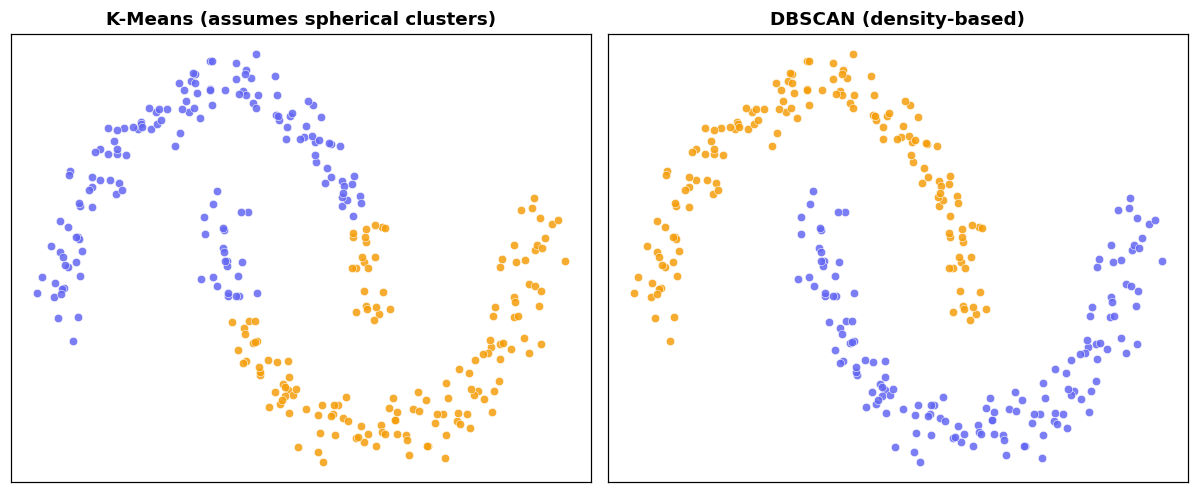

In [ ]:
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for i in range(2):
    pts = X_moons[kmeans_moons.labels_ == i]
    axes[0].scatter(pts[:, 0], pts[:, 1], s=30, color=PALETTE[i], alpha=0.85, edgecolor="white", linewidth=0.4)
axes[0].set_title("K-Means (assumes spherical clusters)", fontweight="bold")
axes[0].set_xticks([]); axes[0].set_yticks([])

ci = 0
for lbl in unique_labels:
    pts = X_moons[db_labels == lbl]
    color = NOISE_COLOR if lbl == -1 else PALETTE[ci % len(PALETTE)]
    axes[1].scatter(pts[:, 0], pts[:, 1], s=30, color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    if lbl != -1:
        ci += 1
axes[1].set_title("DBSCAN (density-based)", fontweight="bold")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()

---
## 5. Choosing the Right Algorithm

| | K-Means | Hierarchical | DBSCAN |
|---|---|---|---|
| **Cluster shape** | Spherical | Nested / arbitrary | Arbitrary |
| **Needs # of clusters?** | Yes (`k`) | No (cut dendrogram) | No (auto-detects) |
| **Handles noise/outliers** | Poorly | Moderately | Very well |
| **Scales to large data** | Yes | No | Yes (with spatial index) |
| **Deterministic result** | No (init-dependent) | Yes | Yes |

### Key takeaways
- **K-Means** — fast and simple. Great default choice when clusters are roughly round and you know `k` in advance.
- **Hierarchical Clustering** — best when you want a full hierarchy of relationships, not just a flat partition, on smaller datasets.
- **DBSCAN** — ideal for irregularly-shaped clusters and data with noise; no need to specify the cluster count.